In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import os


In [2]:
FOLDER_PATH = r"stereo_materials/"
imgs = []

# Add sorted() here to guarantee alphabetical order
file_paths = sorted(glob.glob(os.path.join(FOLDER_PATH,"*")))

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

for file in file_paths:
    if file.lower().endswith(valid_extensions):
        img = cv.imread(file)
        if img is not None:
            imgs.append(img)
            print(f"Loaded img: {file}")

print(f"{len(imgs)=}")

Loaded img: stereo_materials/l1.png
Loaded img: stereo_materials/l2.png
Loaded img: stereo_materials/l3.png
Loaded img: stereo_materials/r1.png
Loaded img: stereo_materials/r2.png
Loaded img: stereo_materials/r3.png
len(imgs)=6


In [3]:
l_imgs = imgs[:3]
r_imgs = imgs[3:]

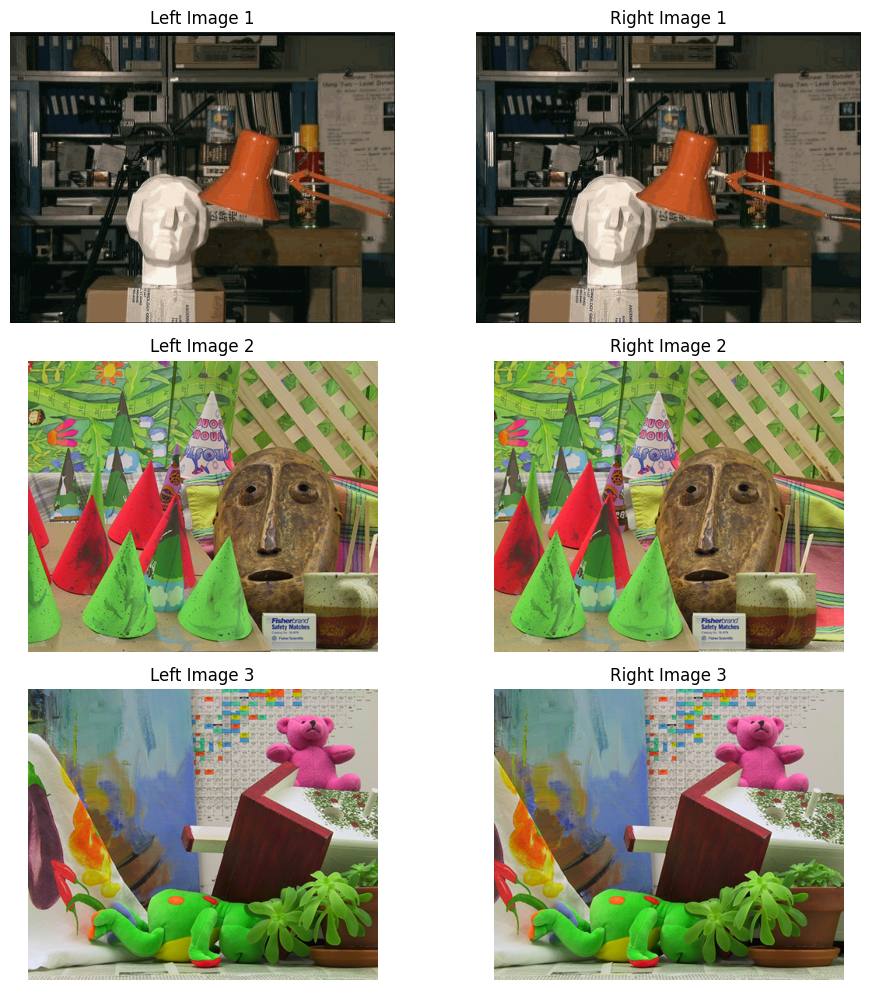

In [4]:
plt.figure(figsize=(10,10))
for i in range(1, 4):
    plt.subplot(3, 2, 2 * i - 1)
    plt.imshow(cv.cvtColor(l_imgs[i-1], cv.COLOR_BGR2RGB))
    plt.title(f"Left Image {i}")
    plt.axis('off')

    plt.subplot(3, 2, 2 * i)
    plt.imshow(cv.cvtColor(r_imgs[i-1], cv.COLOR_BGR2RGB))
    plt.title(f"Right Image {i}")
    plt.axis('off')

plt.tight_layout() 
plt.show()

# DP

In [5]:
class StereoDP:
    
    def __init__(self, sigma=2.0, c0=1.0):
        self.sigma = sigma
        self.c0 = c0

    def _build_dp_matrix(self, row_l, row_r):

        N = len(row_l)
        D = np.zeros((N, N), dtype=np.float32)
    
        d_cost = ((row_l[:, None] - row_r[None, :]) ** 2) / (self.sigma ** 2)  #calculate squared difference costs for row
        D[0, 0] = d_cost[0, 0] # initialization
        
        # accumulating the skip penalty
        for j in range(1, N):
            D[0, j] = D[0, j-1] + self.c0
        for i in range(1, N):
            D[i, 0] = D[i-1, 0] + self.c0

        for i in range(1, N):
            for j in range(1, N):
                cost_match = D[i-1, j-1] + d_cost[i, j]
                cost_skip_l = D[i-1, j] + self.c0
                cost_skip_r = D[i, j-1] + self.c0
                
                D[i, j] = min(cost_match, cost_skip_l, cost_skip_r)
                
        return D

    def _backtrack_path(self, D):
        N = D.shape[0]
        i, j = N - 1, N - 1
        
        dl = np.zeros(N, dtype=np.float32)
        dr = np.zeros(N, dtype=np.float32)

        path = [(i, j)]

        while i > 0 and j > 0:
            options = {
                "match": D[i-1, j-1],
                "skip_l": D[i-1, j],
                "skip_r": D[i, j-1]
            }
            best_move = min(options, key=options.get)
            
            if best_move == "match":
                dl[i] = abs(i - j)  
                dr[j] = abs(i - j)
                i -= 1
                j -= 1
            elif best_move == "skip_l":
                dl[i] = 0            
                i -= 1
            elif best_move == "skip_r":
                dr[j] = 0           
                j -= 1
            path.append((i, j))
                
        while i > 0:
            dl[i] = 0
            i -= 1
            path.append((i, j))

        while j > 0:
            dr[j] = 0
            j -= 1
            path.append((i, j))
            
        return dl, dr, path

    def compute(self, img_left, img_right):
        # Ensure images are floating point for accurate math
        img_l = img_left.astype(np.float32)
        img_r = img_right.astype(np.float32)
        
        rows, cols = img_l.shape
        
        disp_l_full = np.zeros((rows, cols), dtype=np.float32)
        disp_r_full = np.zeros((rows, cols), dtype=np.float32)
        
        print(f"Processing {rows} rows using DP (sigma={self.sigma}, c0={self.c0})...")
        
        for r in range(rows):
            if r % 25 == 0:  
                print(f" -> Completed {r}/{rows} scanlines")
                
            scanline_l = img_l[r, :]
            scanline_r = img_r[r, :]
            
            # Use class methods
            D_matrix = self._build_dp_matrix(scanline_l, scanline_r)
            disp_l, disp_r, _ = self._backtrack_path(D_matrix)
            
            disp_l_full[r, :] = disp_l
            disp_r_full[r, :] = disp_r
            
        print("DP Processing Complete!")
        return disp_l_full, disp_r_full
    
    def plot_alignment(self, row_l, row_r, row_index=0):
        D_matrix = self._build_dp_matrix(row_l, row_r)
        _, _, path = self._backtrack_path(D_matrix)
    
        x_coords = [p[1] for p in path] # Right image indices
        y_coords = [p[0] for p in path] # Left image indices
        
        # Create the plot
        plt.figure(figsize=(8, 8))
        plt.plot(x_coords, y_coords, marker='.', markersize=2, color='blue', linewidth=2)
        
        plt.title(f'Optimal Alignment Path for Scanline {row_index}')
        plt.xlabel('Right Image Pixels ($I_r$) - Horizontal')
        plt.ylabel('Left Image Pixels ($I_l$) - Vertical')
        
        # Invert the axes so (0,0) is at the top left, matching matrix indexing
        plt.gca().invert_yaxis()
        plt.gca().xaxis.tick_top()
        plt.gca().xaxis.set_label_position('top')
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

Processing 289 rows using DP (sigma=2.0, c0=1.0)...
 -> Completed 0/289 scanlines
 -> Completed 25/289 scanlines
 -> Completed 50/289 scanlines
 -> Completed 75/289 scanlines
 -> Completed 100/289 scanlines
 -> Completed 125/289 scanlines
 -> Completed 150/289 scanlines
 -> Completed 175/289 scanlines
 -> Completed 200/289 scanlines
 -> Completed 225/289 scanlines
 -> Completed 250/289 scanlines
 -> Completed 275/289 scanlines
DP Processing Complete!


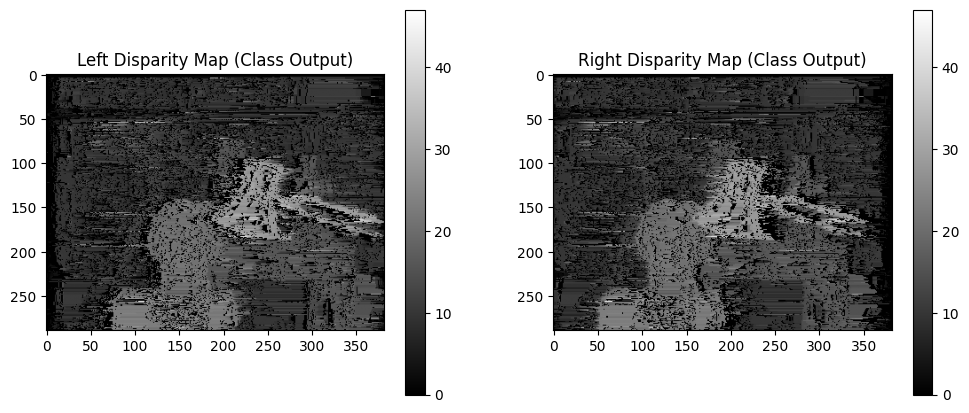

In [6]:
stereo_solver = StereoDP(sigma=2.0, c0=1.0)

left_gray = cv.cvtColor(l_imgs[0],cv.COLOR_RGB2GRAY)
right_gray = cv.cvtColor(r_imgs[0],cv.COLOR_RGB2GRAY)
left_disparity, right_disparity = stereo_solver.compute(left_gray, right_gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Left Disparity Map (Class Output)')
plt.imshow(left_disparity, cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title('Right Disparity Map (Class Output)')
plt.imshow(right_disparity, cmap='gray')
plt.colorbar()

plt.show()

# Bonus


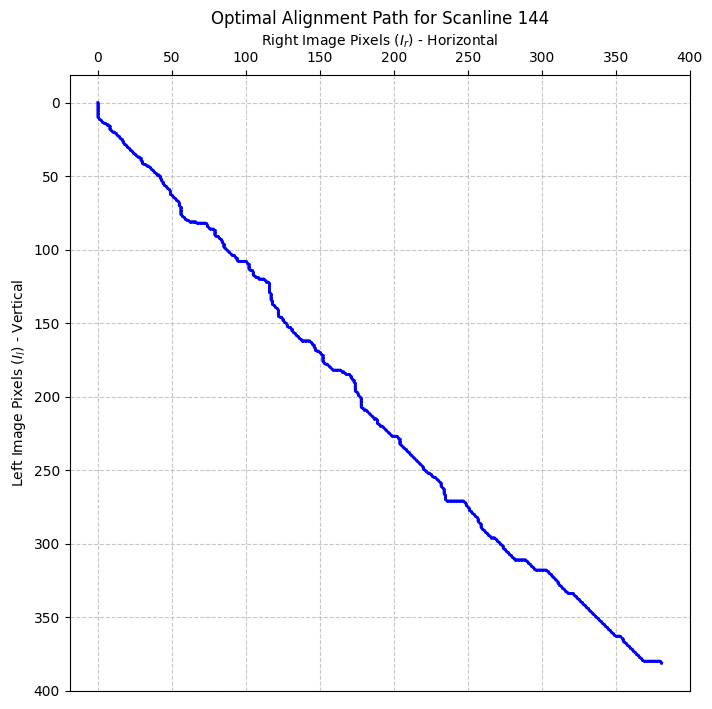

In [7]:
test_row_index = left_gray.shape[0] // 2 

scanline_left = left_gray[test_row_index, :]
scanline_right = right_gray[test_row_index, :]

stereo_solver.plot_alignment(scanline_left, scanline_right, row_index=test_row_index)

# The rest of the images

# 2

Processing 375 rows using DP (sigma=2.0, c0=1.0)...
 -> Completed 0/375 scanlines
 -> Completed 25/375 scanlines
 -> Completed 50/375 scanlines
 -> Completed 75/375 scanlines
 -> Completed 100/375 scanlines
 -> Completed 125/375 scanlines
 -> Completed 150/375 scanlines
 -> Completed 175/375 scanlines
 -> Completed 200/375 scanlines
 -> Completed 225/375 scanlines
 -> Completed 250/375 scanlines
 -> Completed 275/375 scanlines
 -> Completed 300/375 scanlines
 -> Completed 325/375 scanlines
 -> Completed 350/375 scanlines
DP Processing Complete!


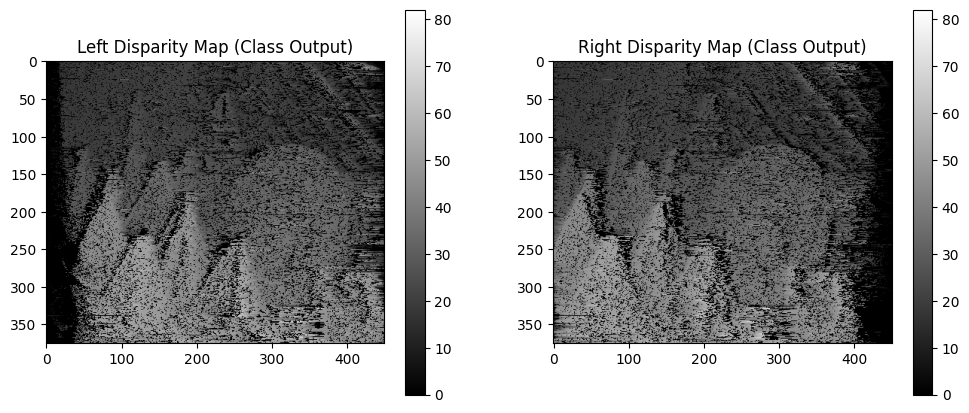

In [ ]:
left_gray = cv.cvtColor(l_imgs[1],cv.COLOR_RGB2GRAY)
right_gray = cv.cvtColor(r_imgs[1],cv.COLOR_RGB2GRAY)
left_disparity, right_disparity = stereo_solver.compute(left_gray, right_gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Left Disparity Map (Class Output)')
plt.imshow(left_disparity, cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title('Right Disparity Map (Class Output)')
plt.imshow(right_disparity, cmap='gray')
plt.colorbar()

plt.show()

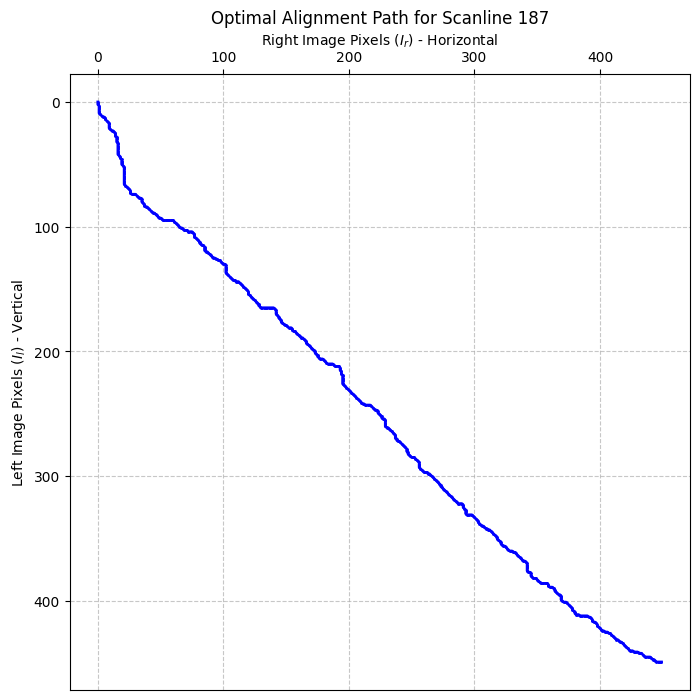

In [ ]:
test_row_index = left_gray.shape[0] // 2 

scanline_left = left_gray[test_row_index, :]
scanline_right = right_gray[test_row_index, :]

stereo_solver.plot_alignment(scanline_left, scanline_right, row_index=test_row_index)

# 3

Processing 375 rows using DP (sigma=2.0, c0=1.0)...
 -> Completed 0/375 scanlines
 -> Completed 25/375 scanlines
 -> Completed 50/375 scanlines
 -> Completed 75/375 scanlines
 -> Completed 100/375 scanlines
 -> Completed 125/375 scanlines
 -> Completed 150/375 scanlines
 -> Completed 175/375 scanlines
 -> Completed 200/375 scanlines
 -> Completed 225/375 scanlines
 -> Completed 250/375 scanlines
 -> Completed 275/375 scanlines
 -> Completed 300/375 scanlines
 -> Completed 325/375 scanlines
 -> Completed 350/375 scanlines
DP Processing Complete!


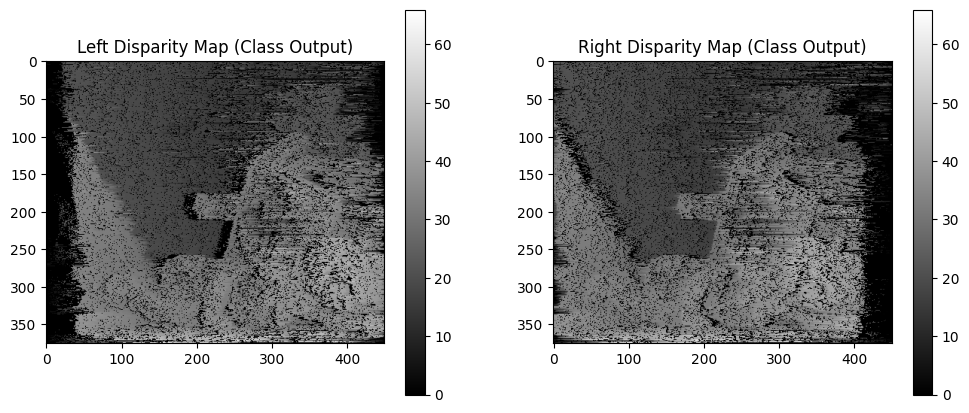

In [ ]:
left_gray = cv.cvtColor(l_imgs[2],cv.COLOR_RGB2GRAY)
right_gray = cv.cvtColor(r_imgs[2],cv.COLOR_RGB2GRAY)
left_disparity, right_disparity = stereo_solver.compute(left_gray, right_gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Left Disparity Map (Class Output)')
plt.imshow(left_disparity, cmap='gray')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title('Right Disparity Map (Class Output)')
plt.imshow(right_disparity, cmap='gray')
plt.colorbar()

plt.show()

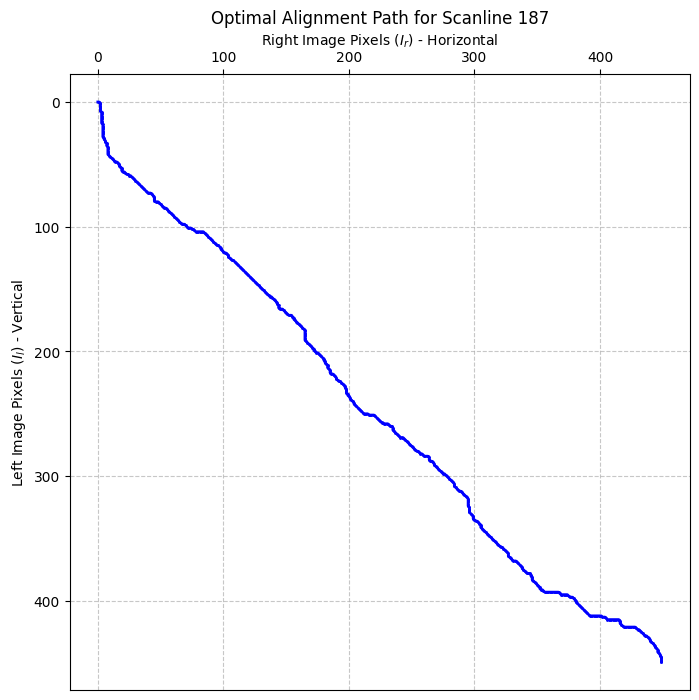

In [ ]:
test_row_index = left_gray.shape[0] // 2 

scanline_left = left_gray[test_row_index, :]
scanline_right = right_gray[test_row_index, :]

stereo_solver.plot_alignment(scanline_left, scanline_right, row_index=test_row_index)